In [132]:
%load_ext autoreload
%autoreload 2 
    
from __init__ import PRP; import sys
sys.path.append(PRP + 'Diffusion_model')
sys.path.append(PRP + 'Results/analysis_scripts/')

import os
from configs.base_config import TrainingConfig
from pipelines.pipeline_tensor import DDPMPipeline_Tensor
from pipelines.State import Observer
import torch
from Diffusion_Model.pipelines.new_constraint import *
from DataLoader import get_dataloader, get_infos
from TransformFields import TransformationPipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
model_path = f'{os.environ["OCEANDATA"]}/models/dino-fusion/tav0h83b/'
pipeline = DDPMPipeline_Tensor.from_pretrained(model_path).to('mps')

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

In [134]:
config = TrainingConfig()
config.data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar'
observer = Observer('data', config)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [216]:
tr = TransformationPipeline(get_infos(config.data_file), config.fields, config.normalisation, device='mps')
train_dataloader = get_dataloader(config.data_file, tr, batch_size=1)
idt = iter(train_dataloader)
data = next(idt)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [136]:
shape   = data.shape

In [137]:
shape

torch.Size([5, 37, 208, 64])

In [288]:
constraint = Constraint() #GradientConstraint(Beta(beta_init=0.1, beta_type='constant'))

projection = OptimProjection(MeanDensityProfile(observer=observer),eps=0.1, max_opt_steps=10)

gen = torch.rand_like(data)

In [340]:
gen = torch.rand_like(data)

In [341]:
gen = gen.requires_grad_(True)

In [342]:
r = (observer.unnormalized(gen, 'file')['toce']**2).sum()

In [343]:
r.backward()

In [344]:
gen.grad.sum()

tensor(nan, device='mps:0')

In [346]:
observer.unnormalized(gen, 'strided')['toce'].shape

torch.Size([1, 18, 199, 62])

In [372]:
field = torch.randn([18, 199, 62])
field[:, 5:-5, 5:-5] = torch.nan
field.requires_grad_(True)

l = (field ** 2).nansum()
l.backward()
print(field.grad.sum())

tensor(nan)


In [374]:
import torch.nn.functional as F 
from einops import rearrange

field = torch.randn([18, 199, 62])
field[:, 5:-5, 5:-5] = torch.nan
field.requires_grad_(True)

field_inter = F.interpolate(rearrange(field, 'z x y -> x y z'), size=(36), mode='linear')
l = (field_inter ** 2).nansum()
l.backward()
print(field.grad.sum())

tensor(nan)


tensor(nan)

In [369]:
l

tensor(nan, grad_fn=<SumBackward0>)

In [308]:
loss = (observer.density(gen).nanmean(dim=(-2,-1))**2).sum()

In [309]:
loss.backward()

In [312]:
gen.grad.isnan().sum(axis=(-2,-1))

tensor([[162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162,
         162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162, 162,
         162, 162, 162, 162, 162, 162, 162, 162,   0]], device='mps:0')

In [290]:
%%time
gen_new = projection(gen)

0.08054155111312866 7
CPU times: user 2.22 s, sys: 390 ms, total: 2.61 s
Wall time: 3.52 s


In [294]:
gen_new.isnan().sum(axis=(-1,-2))

tensor([[ 1134,  1134,  1134,  1134,  1134,  1134,  1134,  1134,  1134,  1134,
          1134, 11890, 11890, 11890, 11890, 11890, 11890, 11890,  1134,  1134,
          1134,  1134,  1134,  1134,  1134,  1134,  1134,  1134,  1134, 11890,
         11890, 11890, 11890, 11890, 11890, 11890,     0]], device='mps:0')

In [237]:
gen_new.nanmean(axis=(-2,-1))

tensor([[0.2969, 0.3010, 0.2998, 0.2982, 0.2809, 0.2636, 0.2486, 0.2332, 0.2292,
         0.2603, 0.3367, 0.4988, 0.4898, 0.5082, 0.5071, 0.5085, 0.4924, 0.5023,
         0.5665, 0.5620, 0.5612, 0.5682, 0.5677, 0.5702, 0.5688, 0.5729, 0.5742,
         0.5689, 0.5517, 0.5203, 0.4794, 0.5026, 0.5057, 0.5032, 0.4913, 0.4912,
         0.4974]], device='mps:0')

In [279]:
masked_field = observer.unnormalized(gen_new, result='masked')
mask = observer.normalizer.masker.mask
torch.where(mask, torch.full_like(masked_field[0], torch.nan), masked_field[0]).nanmean(axis=(-2,-1))

tensor([0.2707, 0.2742, 0.2723, 0.2705, 0.2530, 0.2323, 0.2145, 0.1970, 0.1941,
        0.2294, 0.3138,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
        0.5752, 0.5683, 0.5702, 0.5766, 0.5772, 0.5789, 0.5786, 0.5817, 0.5824,
        0.5776, 0.5589,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
        0.4983], device='mps:0')

In [273]:
masked_field.nanmean(axis=(-2,-1))

tensor([[0.2795, 0.2834, 0.2811, 0.2815, 0.2621, 0.2430, 0.2263, 0.2092, 0.2057,
         0.2400, 0.3215, 0.4964, 0.4883, 0.5060, 0.4794, 0.5298, 0.4903, 0.4898,
         0.5721, 0.5664, 0.5664, 0.5729, 0.5737, 0.5751, 0.5754, 0.5784, 0.5798,
         0.5747, 0.5561, 0.5105, 0.4778, 0.4958, 0.5036, 0.5174, 0.4922, 0.5044,
         0.4981]], device='mps:0')

In [282]:
(mask * masked_field[0]).nansum(axis=(-2,-1))

tensor([218.8974, 226.5416, 220.8061, 244.1671, 215.1286, 223.4138, 228.2057,
        225.4626, 217.6406, 222.1943, 226.5909, 222.3732, 218.7429, 226.6712,
        214.7707, 237.3709, 219.6376, 219.4330, 223.2581, 233.4893, 212.4627,
        216.4084, 220.2014, 216.0876, 223.4282, 223.7908, 231.9374, 225.9536,
        218.5336, 228.7015, 214.0393, 222.1328, 225.6198, 231.7757, 220.4990,
        225.9747, 220.0604], device='mps:0')

In [283]:
masked_field[0]

tensor([[[ 3.6225e-03,  5.8769e-02,  4.1149e-01,  ...,  8.1063e-01,
           4.1742e-01,  5.2924e-01],
         [ 5.7613e-01, -1.2794e-01,  3.7065e-01,  ...,         nan,
                  nan,  5.4139e-01],
         [ 1.7238e-01,  2.2581e-01,  2.5650e-01,  ...,         nan,
                  nan,  8.3379e-01],
         ...,
         [ 6.1590e-01, -4.1637e-02,  3.1665e-01,  ...,         nan,
                  nan,  4.1682e-01],
         [ 6.2212e-01, -4.7801e-02,  5.7366e-01,  ...,         nan,
                  nan,  5.0237e-01],
         [ 3.5764e-01,  3.9122e-01,  1.5110e-01,  ...,  9.1451e-01,
           7.6092e-01,  7.9442e-01]],

        [[ 2.4720e-01,  9.6525e-01,  6.7971e-01,  ...,  5.3175e-01,
           6.1418e-01,  3.2627e-01],
         [ 8.0654e-01,  6.9901e-01,  3.7778e-01,  ...,         nan,
                  nan,  1.9530e-01],
         [ 3.3588e-01,  5.3322e-01,  5.2071e-01,  ...,         nan,
                  nan,  6.4362e-01],
         ...,
         [ 8.5724e-01, -6

In [272]:
(mask[12] == True).sum()

tensor(448, device='mps:0')

In [252]:
observer.unnormalized(gen_new, result='normalized').nanmean(axis=(-2,-1))

tensor([[0.2707, 0.2742, 0.2723, 0.2705, 0.2530, 0.2323, 0.2145, 0.1970, 0.1941,
         0.2294, 0.3138,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
         0.5752, 0.5683, 0.5702, 0.5766, 0.5772, 0.5789, 0.5786, 0.5817, 0.5824,
         0.5776, 0.5589,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
         0.4983]], device='mps:0')

In [233]:
observer.density(gen_new).nanmean(axis=(-2, -1))

tensor([[1025.3687, 1025.4136, 1025.3834, 1025.3795, 1025.3982, 1025.4257,
         1025.4675, 1025.5431, 1025.6559, 1025.7723, 1025.9030, 1026.0280,
         1026.1609, 1026.2955, 1026.4487, 1026.5934, 1026.7454, 1026.8737,
         1026.9948, 1027.0923, 1027.1821,       nan,       nan,       nan,
               nan,       nan,       nan,       nan,       nan,       nan,
               nan,       nan,       nan,       nan,       nan,       nan]],
       device='mps:0')

In [225]:
observer.density(gen_new).nanmean(axis=(-2, -1))

tensor([[1025.3318, 1025.3778, 1025.3490, 1025.3470, 1025.3704, 1025.4052,
         1025.4529, 1025.5312, 1025.6487, 1025.7675, 1025.8964, 1026.0236,
         1026.1630, 1026.2990, 1026.4470, 1026.5852, 1026.7300, 1026.8522,
         1026.9685, 1027.0636, 1027.1533,       nan,       nan,       nan,
               nan,       nan,       nan,       nan,       nan,       nan,
               nan,       nan,       nan,       nan,       nan,       nan]],
       device='mps:0')

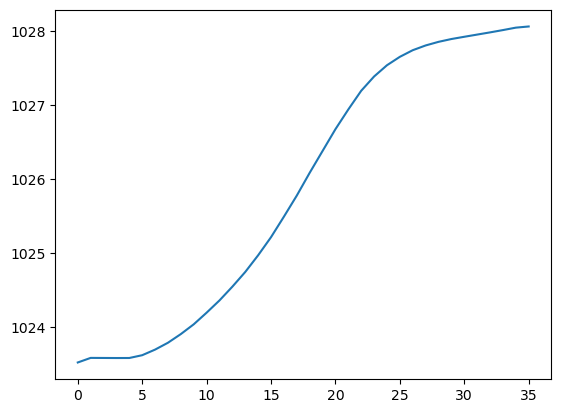

In [292]:
plt.plot(observer.density(gen).nanmean(axis=(-2, -1)).detach().cpu().T)
#plt.plot(observer.density(gen_new).nanmean(axis=(-2, -1)).detach().cpu().T)
#plt.plot(projection.loss.mean_density.cpu(), c='red')

In [187]:
with torch.no_grad() :
    for t in pipeline.progress_bar(pipeline.scheduler.timesteps): #pipeline.scheduler.timesteps
        model_output = pipeline.unet(gen, t).sample
        increment_model = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
        
        constraint_dt = constraint(gen, t) # 𝛼∇C(x)
        
        gen = projection(increment_model - constraint_dt)

  0%|          | 0/1000 [00:00<?, ?it/s]

0.008431166410446167 9
0.008599668741226196 8
0.009790360927581787 7
0.007536500692367554 7
0.006138116121292114 7
0.004914999008178711 7
0.008708566427230835 6
0.008101209998130798 6
0.006876662373542786 6
0.00818905234336853 5
0.009924635291099548 5
0.008971781469881535 5
0.008403301239013672 5
0.009694010019302368 5
0.00838606059551239 5
0.008379951119422913 5
0.008137747645378113 5
0.008190006017684937 5
0.008342429995536804 5
0.009369447827339172 4
0.00759606109932065 5
0.00920972228050232 4
0.009071990847587585 4
0.008367270231246948 5
0.008942320942878723 5
0.00737762451171875 4
0.008921876549720764 4
0.009628713130950928 4
0.008242592215538025 4
0.009399652481079102 4
0.0087004154920578 4
0.00770607590675354 4
0.00873132050037384 4
0.008472949266433716 4
0.009705960750579834 4
0.008659332990646362 4
0.009307071566581726 3
0.008905857801437378 4
0.009920820593833923 3
0.009490877389907837 4
0.007528707385063171 4
0.009158373810350895 3
0.008266047574579716 4
0.008341804146766663

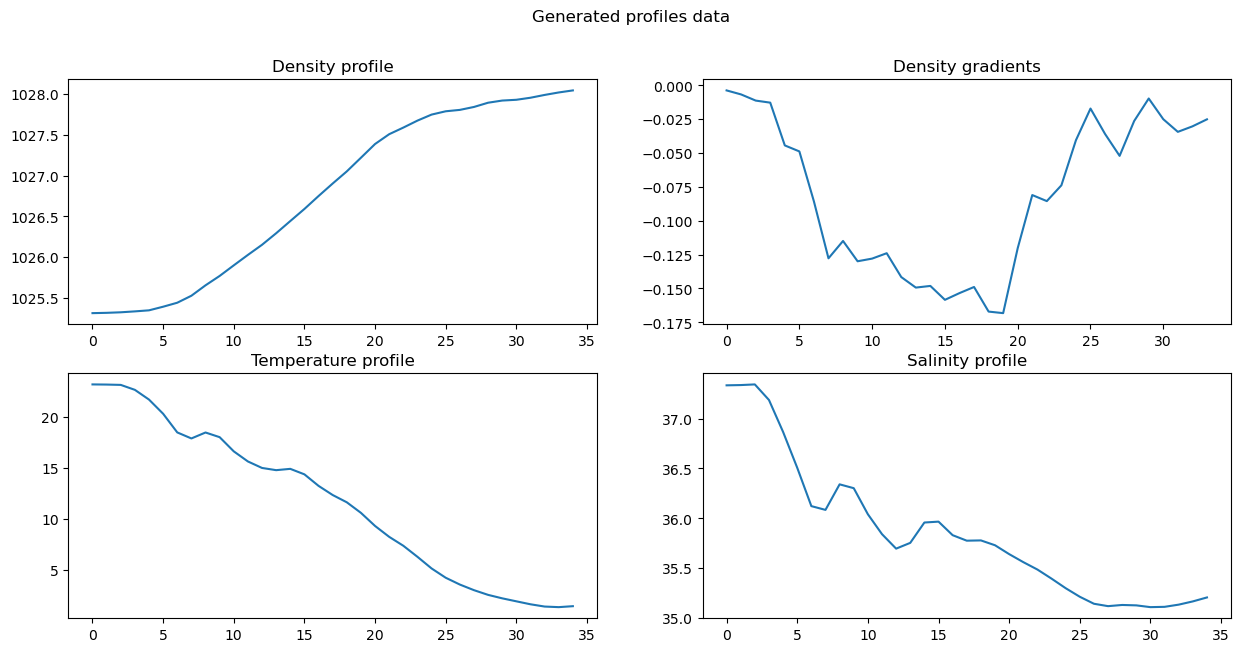

In [188]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles {Gen.name}')
axs[0, 0].set_title('Density profile')
axs[0, 0].plot(observer.density(gen).nanmean(axis=(-1,-2))[:, :-1].T.cpu())

axs[0, 1].set_title('Density gradients')
axs[0, 1].plot(observer.density_gradient(gen).nanmean(axis=(-1,-2))[:, :-1].T.cpu())

axs[1, 0].set_title('Temperature profile')
axs[1, 0].plot(observer.unnormalized(gen)['toce.npy'].nanmean(axis=(-1,-2))[:, :-1].T.cpu())

axs[1, 1].set_title('Salinity profile')
axs[1, 1].plot(observer.unnormalized(gen)['soce.npy'].nanmean(axis=(-1,-2))[:, :-1].T.cpu())

# SAL

In [209]:
constraint = Constraint() #GradientConstraint(Beta(beta_init=0.1, beta_type='constant'))

projection = OptimProjection(MeanGradDensityProfile(observer=observer),eps=0.1, max_opt_steps=10)

gen = torch.randn(*shape, device='mps')

In [ ]:
mu = torch.zeros_like(gen)
gen_z = projection(gen)
rho = 0.1
eta = 0.1

with torch.no_grad() :
    for t in pipeline.progress_bar(pipeline.scheduler.timesteps): #pipeline.scheduler.timesteps
        var = pipeline.scheduler._get_variance(t, None)**0.5

        # Step 1 :
        model_output = pipeline.unet(gen, t).sample
        gen = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
        gen -= rho * (gen - gen_z + mu)
        
        # Step 2 : 
        gen_z = projection(gen + mu + var * torch.randn_like(gen)) # ??

        # Step 3 : 
        mu += eta * (gen - gen_z)

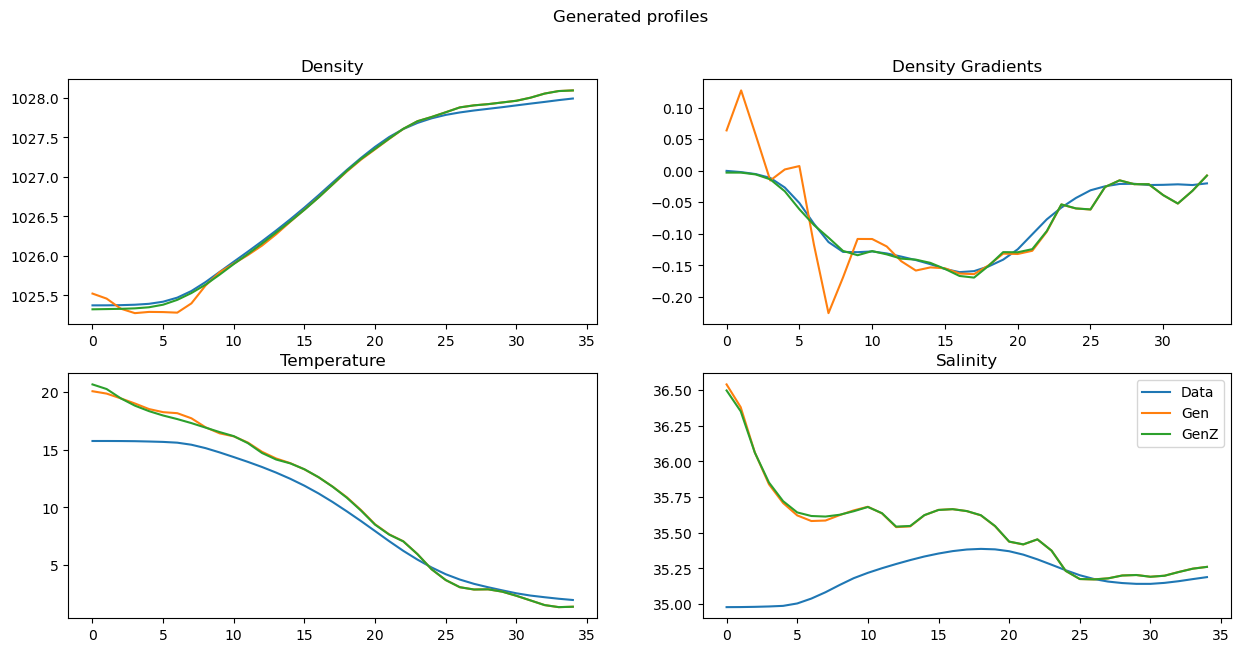

In [233]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles')

funs = {'Density' : observer.density,
        'Density Gradients' :observer.density_gradient,
        'Temperature' : (lambda x : observer.unnormalized(x)['toce.npy']),
        'Salinity' : (lambda x : observer.unnormalized(x)['soce.npy'])}

fs = {'Data' : data, 'Gen' : gen, 'GenZ' : gen_z}

axs = axs.flatten()

for i, (k, v) in enumerate(funs.items()) : 
    axs[i].set_title(k)
    for fk, fv in fs.items() : 
        axs[i].plot(v(fv).nanmean(axis=(-1,-2))[:, :-1].T.cpu(), label=fk)
axs[-1].legend()

# Density Constraint

In [84]:
from copy import deepcopy
from tensordict.tensordict import TensorDict


In [51]:
gen = torch.randn(*shape, device='mps')

In [93]:
infos = deepcopy(observer.normalizer.infos)
infos['mean']['ssh'] = infos['mean']['ssh'][None]
infos['std']['ssh'] = infos['std']['ssh'][None]
infos_stride = {}
infos_stride['mean'] = observer.normalizer.stride_concat(infos['mean'])
infos_stride['std'] = observer.normalizer.stride_concat(infos['std'])
infos_stride = TensorDict(infos_stride, batch_size=[]).to(gen.device)

In [100]:
gen_unormalized = (gen * (3*infos_stride['std'][None])) + infos_stride['mean'][None]

In [101]:
infos_stride['mean'].shape

torch.Size([37, 1, 1])

In [106]:
infos['mean']

TensorDict(
    fields={
        soce: Tensor(shape=torch.Size([36, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        ssh: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        toce: Tensor(shape=torch.Size([36, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)

In [103]:
gen_unormalized.shape

torch.Size([1, 37, 208, 64])

# SAL - Latent

In [36]:
from torch.autograd.functional import vjp

In [25]:
#Density constraint
density_profile_data = torch.tensor(np.loadtxt(f'{PRP}/Results/analysis_scripts/mean_density_train.txt'),
                                    device='mps', dtype=torch.float32)
g = lambda x : observer.density_profile(x)
projection = lambda g_x : density_profile_data[None, :].repeat((g_x.shape[0],1))
soft_projection = lambda g_x, alpha : alpha * density_profile_data[None, :].repeat((g_x.shape[0],1)) + (1-alpha) * g_x


# Temperature / Salinity 
#g = lambda x : x.nanmean(axis=(-2, -1))
#projection = lambda g_x : torch.zeros_like(g_x) # We want null mean

In [34]:
rho = 0.1
eta = 0.1

gen = torch.randn(*shape, device='mps')
mu = torch.zeros_like(g(gen))
gen_z = projection(g(gen))

In [29]:
for t in pipeline.progress_bar(pipeline.scheduler.timesteps): #
    var = pipeline.scheduler._get_variance(t, None)**0.5
    
    
    with torch.no_grad() :
        model_output = pipeline.unet(gen, t).sample
        gen = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
    
    g_x, dg_x_v =  vjp(g, gen, mu + g(gen) - gen_z)
    dg_x_v.nan_to_num_(0.0)
    
    gen -= rho * dg_x_v

    g_gen = g(gen)
    gen_z = projection(g_gen + mu + var * torch.randn_like(g_gen))
    
    mu += eta*(g_gen - gen_z)
    print(t, gen.isnan().sum(), gen.max(), gen.min())
    if gen.isnan().sum() > 0 : 
        break

  0%|          | 0/1000 [00:00<?, ?it/s]

tensor(999) tensor(0, device='mps:0') tensor(5.0235, device='mps:0') tensor(-4.4858, device='mps:0')
tensor(998) tensor(0, device='mps:0') tensor(4.7856, device='mps:0') tensor(-5.1115, device='mps:0')
tensor(997) tensor(0, device='mps:0') tensor(4.3616, device='mps:0') tensor(-4.6826, device='mps:0')
tensor(996) tensor(0, device='mps:0') tensor(4.8047, device='mps:0') tensor(-4.4906, device='mps:0')
tensor(995) tensor(0, device='mps:0') tensor(5.3558, device='mps:0') tensor(-4.9040, device='mps:0')
tensor(994) tensor(0, device='mps:0') tensor(4.9130, device='mps:0') tensor(-4.4545, device='mps:0')
tensor(993) tensor(0, device='mps:0') tensor(4.7898, device='mps:0') tensor(-4.7507, device='mps:0')
tensor(992) tensor(0, device='mps:0') tensor(4.6103, device='mps:0') tensor(-4.3749, device='mps:0')
tensor(991) tensor(0, device='mps:0') tensor(4.7728, device='mps:0') tensor(-4.8694, device='mps:0')
tensor(990) tensor(0, device='mps:0') tensor(4.7636, device='mps:0') tensor(-5.4175, device

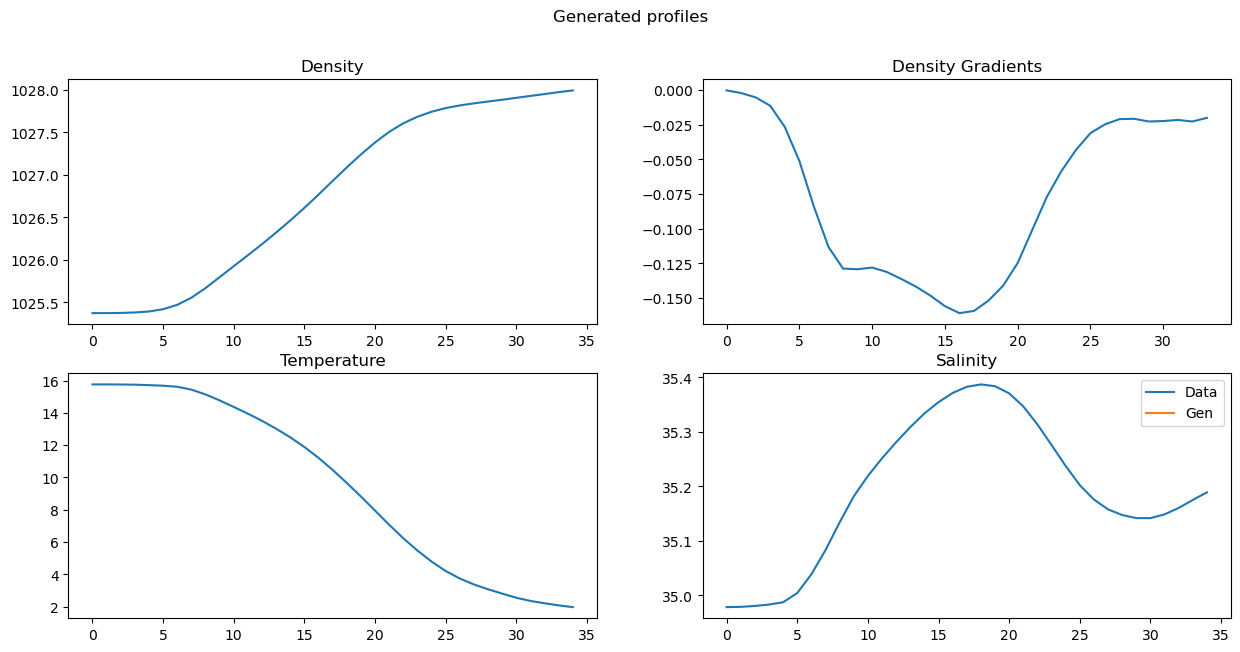

In [33]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles')

funs = {'Density' : observer.density,
        'Density Gradients' :observer.density_gradient,
        'Temperature' : (lambda x : observer.unnormalized(x)['toce.npy']),
        'Salinity' : (lambda x : observer.unnormalized(x)['soce.npy'])}

fs = {'Data' : data, 'Gen' : gen}

axs = axs.flatten()

for i, (k, v) in enumerate(funs.items()) : 
    axs[i].set_title(k)
    for fk, fv in fs.items() : 
        axs[i].plot(v(fv).nanmean(axis=(-1,-2))[:, :-1].T.cpu(), label=fk)
axs[-1].legend()

In [20]:
projection(g(gen))

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')